<a href="https://colab.research.google.com/github/jorgefbarreiros/codes/blob/main/myhank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Searching steady-state interest rate
Initial bracket: r_lo=-0.0100, excess=-4.237300 | r_hi=0.1000, excess=55.000000
Bisection 00: r=0.04500000, excess=5.13535941e+01, C_gap=2.311e+00
Bisection 01: r=0.01750000, excess=-1.73179799e+00, C_gap=-3.031e-02
Bisection 02: r=0.03125000, excess=4.33785338e+00, C_gap=1.356e-01
Bisection 03: r=0.02437500, excess=1.68188868e-01, C_gap=4.099e-03
Bisection 04: r=0.02093750, excess=-9.35177453e-01, C_gap=-1.958e-02
Bisection 05: r=0.02265625, excess=-4.30897651e-01, C_gap=-9.763e-03
Bisection 06: r=0.02351563, excess=-1.44766435e-01, C_gap=-3.404e-03
Bisection 07: r=0.02394531, excess=8.11888429e-03, C_gap=1.945e-04
Bisection 08: r=0.02373047, excess=-6.91516937e-02, C_gap=-1.641e-03
Bisection 09: r=0.02383789, excess=-3.07261198e-02, C_gap=-7.324e-04
Bisection 10: r=0.02389160, excess=-1.13610294e-02, C_gap=-2.716e-04
Bisection 20: r=0.02392281, excess=-3.76659297e-05, C_gap=-1.060e-06

================ STEADY STATE ================

r_ss          

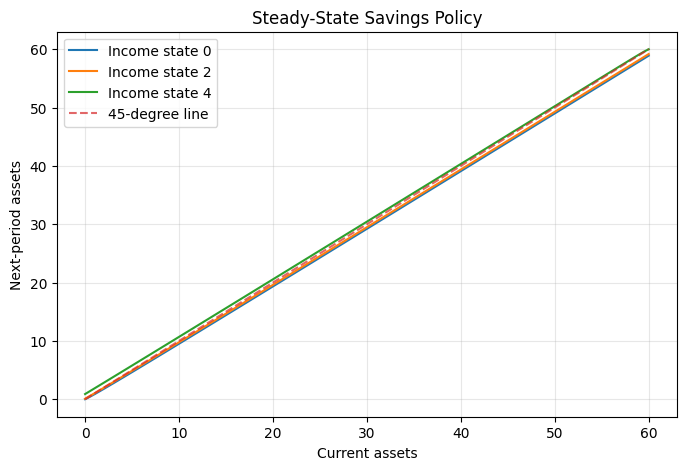

Saved: figures_hank_nk_ginis/steady_state_wealth_distribution.png


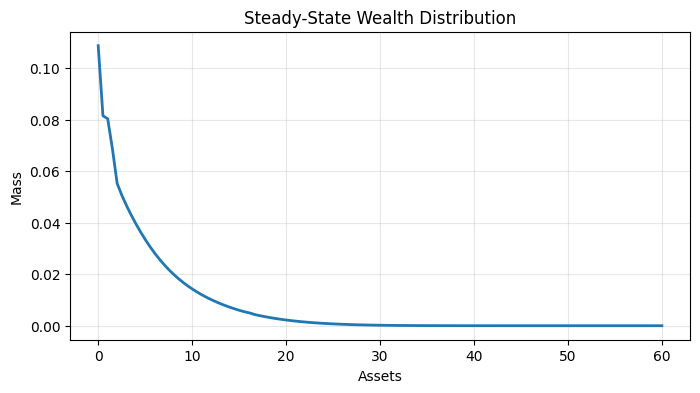

Newton iter 00 | max residual = 9.663e-03
Newton iter 01 | max residual = 6.294e-03
Newton iter 02 | max residual = 4.098e-03
Newton iter 03 | max residual = 2.660e-03
Newton iter 04 | max residual = 1.731e-03
Newton iter 05 | max residual = 1.122e-03
Newton iter 06 | max residual = 7.301e-04
Newton iter 07 | max residual = 4.746e-04
Newton iter 08 | max residual = 3.088e-04
Newton iter 09 | max residual = 2.006e-04
Newton iter 10 | max residual = 1.304e-04
Newton iter 11 | max residual = 8.517e-05
Saved: figures_hank_nk_ginis/macro_irfs_monetary.png


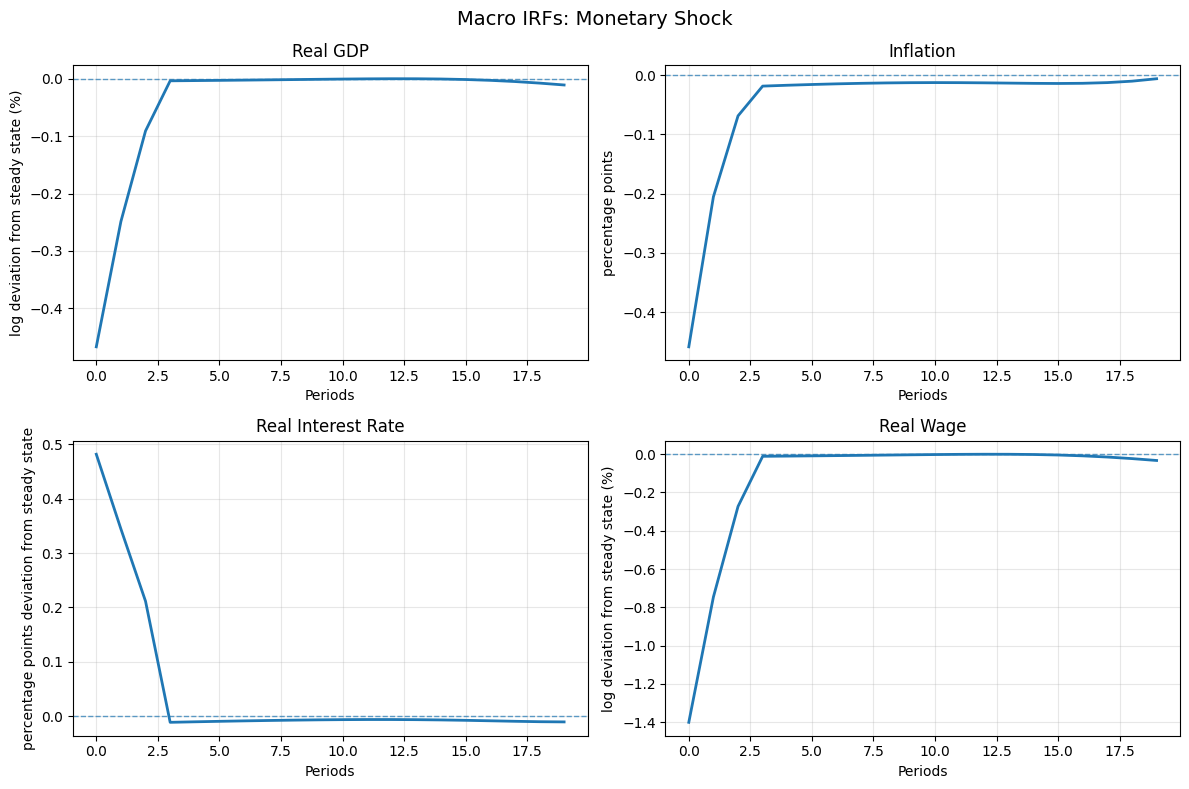

Saved: figures_hank_nk_ginis/consumption_group_irfs_monetary.png


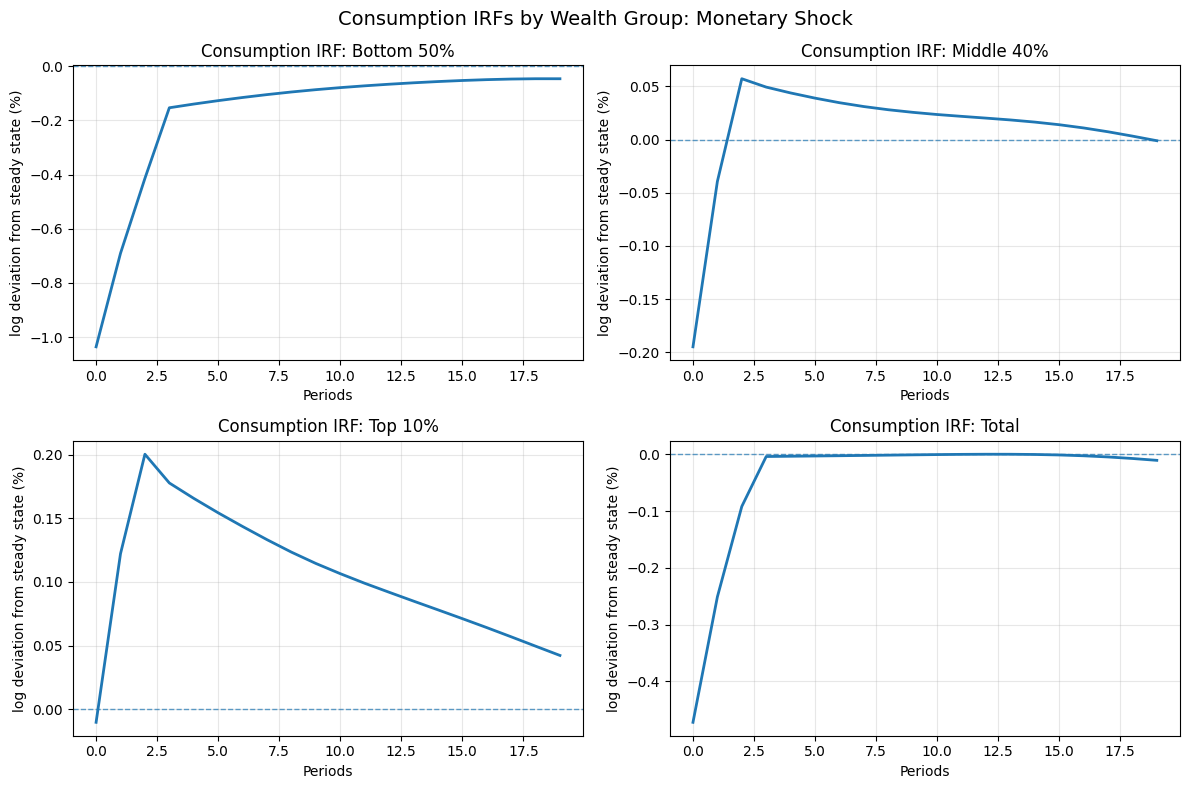

Saved: figures_hank_nk_ginis/gini_paths_monetary.png


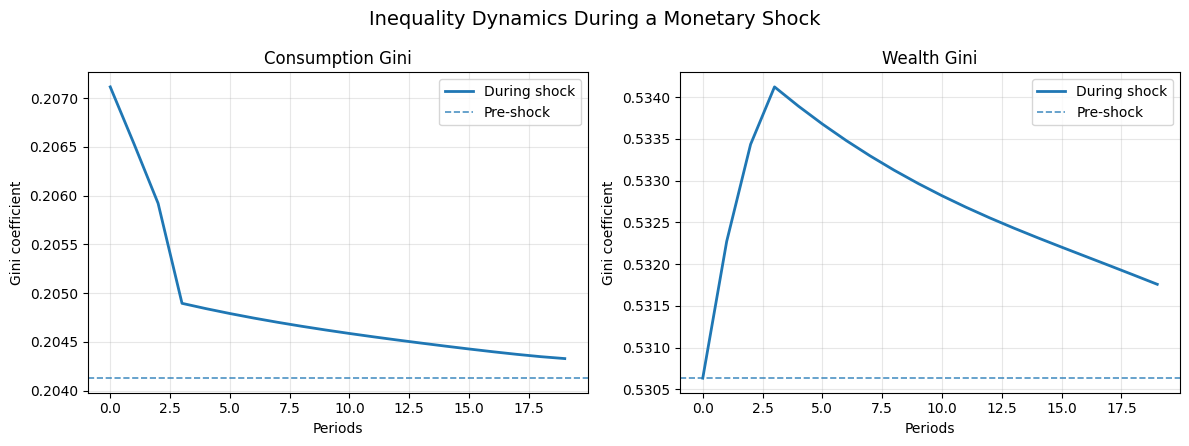


All PNGs saved in: figures_hank_nk_ginis



In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from dataclasses import dataclass


# =========================================================
# 0. OUTPUT FOLDER
# =========================================================
OUTPUT_DIR = "figures_hank_nk_ginis"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================================
# 1. UTILITIES
# =========================================================
def stationary_markov(P):
    eigvals, eigvecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    pi = pi / pi.sum()
    return pi


def rouwenhorst(n: int, rho: float, sigma_eps: float):
    p = (1.0 + rho) / 2.0
    q = p

    P = np.array([[1.0]])
    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += p * P
        P_new[:-1, 1:] += (1.0 - p) * P
        P_new[1:, :-1] += (1.0 - q) * P
        P_new[1:, 1:] += q * P
        P = P_new
        P[1:-1, :] /= 2.0

    sigma_x = sigma_eps / np.sqrt(1.0 - rho**2)
    x = np.linspace(-sigma_x * np.sqrt(n - 1), sigma_x * np.sqrt(n - 1), n)
    z = np.exp(x)

    pi = stationary_markov(P)
    z = z / np.dot(pi, z)
    return z, P


def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")


# =========================================================
# 2. PARAMETERS
# =========================================================
@dataclass
class HHParams:
    beta: float = 0.96
    sigma: float = 2.0

    a_min: float = 0.0
    a_max: float = 60.0
    n_a: int = 120

    n_z: int = 5
    rho_z: float = 0.92
    sigma_eps_z: float = 0.20

    egm_max_iter: int = 1500
    egm_tol: float = 1e-9

    dist_max_iter: int = 15000
    dist_tol: float = 1e-11


@dataclass
class NKParams:
    A_ss: float = 1.0
    epsilon_p: float = 6.0
    theta_p: float = 0.75
    phi_n: float = 1.0

    phi_pi: float = 1.5
    phi_y: float = 0.10

    B_g_ss: float = 5.0

    T: int = 20
    newton_max_iter: int = 12
    newton_tol: float = 1e-6
    newton_step: float = 1e-5
    damp: float = 0.35

    ss_excess_tol: float = 1e-5
    ss_r_tol: float = 1e-8


@dataclass
class SteadyState:
    r: float
    R: float
    Y: float
    C: float
    N: float
    w: float
    mc: float
    div: float
    tax: float
    chi: float
    i_nom: float
    pi: float
    B_g: float

    agrid: np.ndarray
    zgrid: np.ndarray
    Pz: np.ndarray
    pi_z: np.ndarray

    a_pol: np.ndarray
    c_pol: np.ndarray
    Va: np.ndarray
    dist: np.ndarray
    A_hh: float


@dataclass
class TransitionResult:
    Y: np.ndarray
    C: np.ndarray
    N: np.ndarray
    w: np.ndarray
    mc: np.ndarray
    pi: np.ndarray
    i_nom: np.ndarray
    r_real: np.ndarray
    div: np.ndarray
    taxes: np.ndarray
    assets: np.ndarray
    goods_residual: np.ndarray
    nkpc_residual: np.ndarray
    asset_mkt_residual: np.ndarray
    a_pol_path: np.ndarray
    c_pol_path: np.ndarray
    dist_path: np.ndarray


# =========================================================
# 3. HOUSEHOLD BLOCK
# =========================================================
def build_hh_grids(hh: HHParams):
    agrid = np.linspace(hh.a_min, hh.a_max, hh.n_a)
    zgrid, Pz = rouwenhorst(hh.n_z, hh.rho_z, hh.sigma_eps_z)
    pi_z = stationary_markov(Pz)
    return agrid, zgrid, Pz, pi_z


def _interp_policy_single(a_now_endo, a_prime_grid, agrid, a_min, a_max):
    a_pol = jnp.interp(agrid, a_now_endo, a_prime_grid)
    a_pol = jnp.where(agrid <= a_now_endo[0], a_min, a_pol)
    a_pol = jnp.where(agrid >= a_now_endo[-1], a_max, a_pol)
    return a_pol


@jax.jit
def egm_step_jax(Va_next, R, labor_income, net_transfer, beta, sigma, agrid, Pz, a_min, a_max):
    EVa = Pz @ Va_next
    c_endo = (beta * EVa) ** (-1.0 / sigma)
    a_now_endo = (c_endo + agrid[None, :] - labor_income[:, None] - net_transfer) / R

    interp_one = lambda aendo: _interp_policy_single(aendo, agrid, agrid, a_min, a_max)
    a_pol = jax.vmap(interp_one)(a_now_endo)

    c_pol = R * agrid[None, :] + labor_income[:, None] + net_transfer - a_pol
    c_pol = jnp.maximum(c_pol, 1e-12)
    Va = R * c_pol ** (-sigma)

    return a_pol, c_pol, Va


def solve_hh_steady_state(hh: HHParams, R, labor_scale, net_transfer, agrid, zgrid, Pz):
    y = labor_scale * zgrid
    Va = np.ones((hh.n_z, hh.n_a)) * (
        0.1 + R * np.maximum(y[:, None] + net_transfer + agrid[None, :] + 1e-3, 1e-3)
    ) ** (-hh.sigma)

    for _ in range(hh.egm_max_iter):
        a_pol, c_pol, Va_new = egm_step_jax(
            jnp.array(Va),
            float(R),
            jnp.array(y),
            float(net_transfer),
            hh.beta,
            hh.sigma,
            jnp.array(agrid),
            jnp.array(Pz),
            hh.a_min,
            hh.a_max,
        )
        err = np.max(np.abs(np.array(Va_new) - Va))
        Va = np.array(Va_new)
        if err < hh.egm_tol:
            break

    return np.array(a_pol), np.array(c_pol), Va


def stationary_distribution_continuous(a_pol, Pz, agrid, tol=1e-12, max_iter=15000):
    nz, na = a_pol.shape
    dist = np.ones((nz, na)) / (nz * na)

    for _ in range(max_iter):
        newdist = np.zeros_like(dist)

        for iz in range(nz):
            for ia in range(na):
                mass = dist[iz, ia]
                ap = a_pol[iz, ia]

                if ap <= agrid[0]:
                    j = 0
                    jp = 0
                    w_right = 0.0
                    w_left = 1.0
                elif ap >= agrid[-1]:
                    j = na - 1
                    jp = j
                    w_right = 0.0
                    w_left = 1.0
                else:
                    j = np.searchsorted(agrid, ap) - 1
                    jp = j + 1
                    w_right = (ap - agrid[j]) / (agrid[jp] - agrid[j])
                    w_left = 1.0 - w_right

                for izp in range(nz):
                    p = Pz[iz, izp]
                    newdist[izp, j] += mass * p * w_left
                    if jp != j:
                        newdist[izp, jp] += mass * p * w_right

        err = np.max(np.abs(newdist - dist))
        dist = newdist
        if err < tol:
            break

    return dist / dist.sum()


def aggregate_from_dist(dist, a_pol, c_pol):
    A = float(np.sum(dist * a_pol))
    C = float(np.sum(dist * c_pol))
    return A, C


def backward_household_path(hh: HHParams, ss: SteadyState, R_path, labor_scale_path, net_transfer_path):
    T = len(R_path)
    nz, na = hh.n_z, hh.n_a

    Va_path = np.zeros((T + 1, nz, na))
    a_pol_path = np.zeros((T, nz, na))
    c_pol_path = np.zeros((T, nz, na))

    Va_path[T] = ss.Va.copy()

    for t in range(T - 1, -1, -1):
        a_pol_t, c_pol_t, Va_t = egm_step_jax(
            jnp.array(Va_path[t + 1]),
            float(R_path[t]),
            jnp.array(labor_scale_path[t] * ss.zgrid),
            float(net_transfer_path[t]),
            hh.beta,
            hh.sigma,
            jnp.array(ss.agrid),
            jnp.array(ss.Pz),
            hh.a_min,
            hh.a_max,
        )
        a_pol_path[t] = np.array(a_pol_t)
        c_pol_path[t] = np.array(c_pol_t)
        Va_path[t] = np.array(Va_t)

    return a_pol_path, c_pol_path, Va_path


def forward_distribution_path(ss: SteadyState, a_pol_path):
    T, nz, na = a_pol_path.shape
    dist_path = np.zeros((T + 1, nz, na))
    dist_path[0] = ss.dist.copy()

    for t in range(T):
        newdist = np.zeros((nz, na))

        for iz in range(nz):
            for ia in range(na):
                mass = dist_path[t, iz, ia]
                ap = a_pol_path[t, iz, ia]

                if ap <= ss.agrid[0]:
                    j = 0
                    jp = 0
                    w_right = 0.0
                    w_left = 1.0
                elif ap >= ss.agrid[-1]:
                    j = len(ss.agrid) - 1
                    jp = j
                    w_right = 0.0
                    w_left = 1.0
                else:
                    j = np.searchsorted(ss.agrid, ap) - 1
                    jp = j + 1
                    w_right = (ap - ss.agrid[j]) / (ss.agrid[jp] - ss.agrid[j])
                    w_left = 1.0 - w_right

                for izp in range(len(ss.zgrid)):
                    p = ss.Pz[iz, izp]
                    newdist[izp, j] += mass * p * w_left
                    if jp != j:
                        newdist[izp, jp] += mass * p * w_right

        dist_path[t + 1] = newdist / newdist.sum()

    return dist_path


def household_transition_given_aggregates(hh: HHParams, ss: SteadyState, R_path, labor_scale_path, net_transfer_path):
    a_pol_path, c_pol_path, _ = backward_household_path(
        hh, ss, R_path, labor_scale_path, net_transfer_path
    )
    dist_path = forward_distribution_path(ss, a_pol_path)

    T = len(R_path)
    C_path = np.zeros(T)
    A_path = np.zeros(T)

    for t in range(T):
        C_path[t] = np.sum(dist_path[t] * c_pol_path[t])
        A_path[t] = np.sum(dist_path[t] * a_pol_path[t])

    return C_path, A_path, a_pol_path, c_pol_path, dist_path


# =========================================================
# 4. NK BLOCK
# =========================================================
def nk_kappa(beta, theta_p, epsilon_p, phi_n):
    return ((1.0 - theta_p) * (1.0 - beta * theta_p) / theta_p) * (1.0 + phi_n)


def markup_ss(epsilon_p):
    return epsilon_p / (epsilon_p - 1.0)


# =========================================================
# 5. STEADY STATE: DIRECT BISECTION
# =========================================================
def solve_steady_state(hh: HHParams, nk: NKParams, verbose=True):
    agrid, zgrid, Pz, pi_z = build_hh_grids(hh)

    Y_ss = 1.0
    C_target = 1.0
    N_ss = Y_ss / nk.A_ss

    mu_p = markup_ss(nk.epsilon_p)
    mc_ss = 1.0 / mu_p
    w_ss = mc_ss * nk.A_ss
    div_ss = Y_ss - w_ss * N_ss

    def asset_excess(r):
        R = 1.0 + r
        if R <= 0:
            return np.nan, None

        tax_ss = r * nk.B_g_ss
        net_transfer_ss = div_ss - tax_ss
        labor_scale = w_ss * N_ss

        a_pol, c_pol, Va = solve_hh_steady_state(
            hh, R, labor_scale, net_transfer_ss, agrid, zgrid, Pz
        )
        dist = stationary_distribution_continuous(
            a_pol, Pz, agrid, tol=hh.dist_tol, max_iter=hh.dist_max_iter
        )
        A_hh, C_hh = aggregate_from_dist(dist, a_pol, c_pol)

        sol = {
            "A_hh": A_hh,
            "C_hh": C_hh,
            "a_pol": a_pol,
            "c_pol": c_pol,
            "Va": Va,
            "dist": dist,
            "goods_gap": C_hh - C_target,
        }
        return A_hh - nk.B_g_ss, sol

    r_lo, r_hi = -0.01, 0.10
    ex_lo, _ = asset_excess(r_lo)
    ex_hi, _ = asset_excess(r_hi)

    if verbose:
        print("Searching steady-state interest rate")
        print(f"Initial bracket: r_lo={r_lo:.4f}, excess={ex_lo:.6f} | r_hi={r_hi:.4f}, excess={ex_hi:.6f}")

    expand = 0
    while (np.isnan(ex_lo) or np.isnan(ex_hi) or ex_lo * ex_hi > 0) and expand < 14:
        r_lo -= 0.01
        r_hi += 0.02
        ex_lo, _ = asset_excess(r_lo)
        ex_hi, _ = asset_excess(r_hi)
        expand += 1
        if verbose:
            print(f"Expand {expand:02d}: r_lo={r_lo:.4f}, excess={ex_lo:.6f} | r_hi={r_hi:.4f}, excess={ex_hi:.6f}")

    if np.isnan(ex_lo) or np.isnan(ex_hi) or ex_lo * ex_hi > 0:
        raise RuntimeError(
            "Could not bracket steady-state interest rate.\n"
            f"Last values: r_lo={r_lo:.4f}, ex_lo={ex_lo}, r_hi={r_hi:.4f}, ex_hi={ex_hi}\n"
            "Try increasing B_g_ss or lowering beta."
        )

    for it in range(80):
        r_mid = 0.5 * (r_lo + r_hi)
        ex_mid, sol_mid = asset_excess(r_mid)

        if verbose and (it < 10 or it % 10 == 0):
            print(
                f"Bisection {it:02d}: r={r_mid:.8f}, excess={ex_mid:.8e}, "
                f"C_gap={sol_mid['goods_gap']:.3e}"
            )

        if abs(ex_mid) < nk.ss_excess_tol or abs(r_hi - r_lo) < nk.ss_r_tol:
            r_ss = r_mid
            sol_ss = sol_mid
            break

        if ex_lo * ex_mid < 0:
            r_hi = r_mid
        else:
            r_lo = r_mid
            ex_lo = ex_mid
    else:
        r_ss = r_mid
        sol_ss = sol_mid

    chi = w_ss / (N_ss ** nk.phi_n * C_target ** hh.sigma)

    ss = SteadyState(
        r=r_ss,
        R=1.0 + r_ss,
        Y=Y_ss,
        C=C_target,
        N=N_ss,
        w=w_ss,
        mc=mc_ss,
        div=div_ss,
        tax=r_ss * nk.B_g_ss,
        chi=chi,
        i_nom=r_ss,
        pi=0.0,
        B_g=nk.B_g_ss,
        agrid=agrid,
        zgrid=zgrid,
        Pz=Pz,
        pi_z=pi_z,
        a_pol=sol_ss["a_pol"],
        c_pol=sol_ss["c_pol"],
        Va=sol_ss["Va"],
        dist=sol_ss["dist"],
        A_hh=sol_ss["A_hh"],
    )
    return ss


# =========================================================
# 6. TRANSITION EQUILIBRIUM
# =========================================================
def pack_x(yhat, pi):
    return np.concatenate([yhat, pi])


def unpack_x(x, T):
    yhat = x[:T]
    pi = x[T:]
    return yhat, pi


def equilibrium_residuals(x, hh: HHParams, nk: NKParams, ss: SteadyState, A_path, mp_shock, B_g_path):
    T = nk.T
    beta = hh.beta
    kappa = nk_kappa(beta, nk.theta_p, nk.epsilon_p, nk.phi_n)

    yhat, pi = unpack_x(x, T)
    Y = ss.Y * np.exp(yhat)

    # terminal anchor: inflation returns to 0
    pi_lead = np.zeros(T)
    pi_lead[:-1] = pi[1:]
    pi_lead[-1] = 0.0

    i_nom = (1.0 + ss.i_nom) * ((1.0 + np.maximum(pi, -0.99)) ** nk.phi_pi) * ((Y / ss.Y) ** nk.phi_y) * np.exp(mp_shock) - 1.0
    i_nom = np.maximum(i_nom, -0.999)

    R_real = (1.0 + i_nom) / (1.0 + pi_lead)
    r_real = R_real - 1.0

    N = Y / A_path
    w = ss.chi * (N ** nk.phi_n) * (Y ** hh.sigma)
    mc = w / A_path
    mc_hat = np.log(mc / ss.mc)

    div = Y - w * N
    taxes = r_real * B_g_path
    net_transfer = div - taxes

    labor_scale = w * N
    C_hh, A_hh, _, _, _ = household_transition_given_aggregates(
        hh, ss, R_real, labor_scale, net_transfer
    )

    goods_res = Y - C_hh
    nkpc_res = pi - beta * pi_lead - kappa * mc_hat

    return np.concatenate([goods_res, nkpc_res])


def finite_diff_jacobian(fun, x, h=1e-5):
    n = len(x)
    f0 = fun(x)
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        xp = x.copy()
        xm = x.copy()
        xp[j] += h
        xm[j] -= h
        fp = fun(xp)
        fm = fun(xm)
        J[:, j] = (fp - fm) / (2.0 * h)
    return f0, J


def solve_transition(hh: HHParams, nk: NKParams, ss: SteadyState, A_path=None, mp_shock=None, B_g_path=None, verbose=True):
    T = nk.T

    if A_path is None:
        A_path = np.ones(T) * nk.A_ss
    if mp_shock is None:
        mp_shock = np.zeros(T)
    if B_g_path is None:
        B_g_path = np.ones(T) * ss.B_g

    x = pack_x(np.zeros(T), np.zeros(T))

    def fun_local(xx):
        return equilibrium_residuals(xx, hh, nk, ss, A_path, mp_shock, B_g_path)

    for it in range(nk.newton_max_iter):
        fval, J = finite_diff_jacobian(fun_local, x, h=nk.newton_step)
        err = np.max(np.abs(fval))
        if verbose:
            print(f"Newton iter {it:02d} | max residual = {err:.3e}")

        if err < nk.newton_tol:
            break

        dx = np.linalg.solve(J, -fval)
        x = x + nk.damp * dx

    yhat, pi = unpack_x(x, T)
    Y = ss.Y * np.exp(yhat)

    pi_lead = np.zeros(T)
    pi_lead[:-1] = pi[1:]
    pi_lead[-1] = 0.0

    i_nom = (1.0 + ss.i_nom) * ((1.0 + np.maximum(pi, -0.99)) ** nk.phi_pi) * ((Y / ss.Y) ** nk.phi_y) * np.exp(mp_shock) - 1.0
    i_nom = np.maximum(i_nom, -0.999)

    R_real = (1.0 + i_nom) / (1.0 + pi_lead)
    r_real = R_real - 1.0

    N = Y / A_path
    w = ss.chi * (N ** nk.phi_n) * (Y ** hh.sigma)
    mc = w / A_path
    div = Y - w * N
    taxes = r_real * B_g_path
    net_transfer = div - taxes

    labor_scale = w * N
    C_hh, A_hh, a_pol_path, c_pol_path, dist_path = household_transition_given_aggregates(
        hh, ss, R_real, labor_scale, net_transfer
    )

    goods_res = Y - C_hh
    kappa = nk_kappa(hh.beta, nk.theta_p, nk.epsilon_p, nk.phi_n)
    nkpc_res = pi - hh.beta * pi_lead - kappa * np.log(mc / ss.mc)
    asset_res = A_hh - B_g_path

    return TransitionResult(
        Y=Y,
        C=C_hh,
        N=N,
        w=w,
        mc=mc,
        pi=pi,
        i_nom=i_nom,
        r_real=r_real,
        div=div,
        taxes=taxes,
        assets=A_hh,
        goods_residual=goods_res,
        nkpc_residual=nkpc_res,
        asset_mkt_residual=asset_res,
        a_pol_path=a_pol_path,
        c_pol_path=c_pol_path,
        dist_path=dist_path,
    )


# =========================================================
# 7. DISTRIBUTIONAL STATISTICS
# =========================================================
def weighted_gini(values, weights):
    values = np.asarray(values).reshape(-1)
    weights = np.asarray(weights).reshape(-1)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        return np.nan

    if np.min(values) < 0:
        values = values - np.min(values)

    if np.allclose(values.sum(), 0):
        return 0.0

    order = np.argsort(values)
    x = values[order]
    w = weights[order]

    W = np.sum(w)
    wx = w * x
    X = np.sum(wx)

    cw = np.cumsum(w) / W
    cwx = np.cumsum(wx) / X

    cw_prev = np.concatenate(([0.0], cw[:-1]))
    cwx_prev = np.concatenate(([0.0], cwx[:-1]))

    B = np.sum((cwx + cwx_prev) * (cw - cw_prev)) / 2.0
    return 1.0 - 2.0 * B


def compute_gini_paths(ss: SteadyState, tr: TransitionResult):
    wealth_grid = np.tile(ss.agrid[None, :], (len(ss.zgrid), 1))

    gini_wealth_ss = weighted_gini(wealth_grid.reshape(-1), ss.dist.reshape(-1))
    gini_cons_ss = weighted_gini(ss.c_pol.reshape(-1), ss.dist.reshape(-1))

    T = tr.c_pol_path.shape[0]
    gini_wealth_path = np.zeros(T)
    gini_cons_path = np.zeros(T)

    for t in range(T):
        gini_wealth_path[t] = weighted_gini(
            wealth_grid.reshape(-1),
            tr.dist_path[t].reshape(-1)
        )
        gini_cons_path[t] = weighted_gini(
            tr.c_pol_path[t].reshape(-1),
            tr.dist_path[t].reshape(-1)
        )

    return gini_wealth_ss, gini_cons_ss, gini_wealth_path, gini_cons_path


def percentile_mean_consumption(dist, wealth_grid, c_grid, groups=((0.0, 0.5), (0.5, 0.9), (0.9, 1.0))):
    masses = dist.reshape(-1)
    wealth = wealth_grid.reshape(-1)
    cons = c_grid.reshape(-1)

    order = np.argsort(wealth)
    masses = masses[order]
    cons = cons[order]

    cum_pop = np.cumsum(masses)
    means = []

    for p0, p1 in groups:
        val_sum = 0.0
        mass_sum = 0.0
        prev_cum = 0.0
        for m, c, cp in zip(masses, cons, cum_pop):
            seg_left = prev_cum
            seg_right = cp
            overlap = max(0.0, min(seg_right, p1) - max(seg_left, p0))
            if overlap > 0:
                frac = overlap / (seg_right - seg_left)
                val_sum += frac * m * c
                mass_sum += frac * m
            prev_cum = cp
        means.append(val_sum / mass_sum if mass_sum > 1e-14 else np.nan)

    return np.array(means)


def compute_group_consumption_paths(ss: SteadyState, tr: TransitionResult):
    groups = ((0.0, 0.5), (0.5, 0.9), (0.9, 1.0))
    labels = ["Bottom 50%", "Middle 40%", "Top 10%"]

    wealth_grid = np.tile(ss.agrid[None, :], (len(ss.zgrid), 1))
    ss_group_c = percentile_mean_consumption(ss.dist, wealth_grid, ss.c_pol, groups)

    T = tr.c_pol_path.shape[0]
    group_c_path = np.zeros((T, 3))
    total_c_path = np.zeros(T)

    for t in range(T):
        group_c_path[t] = percentile_mean_consumption(
            tr.dist_path[t], wealth_grid, tr.c_pol_path[t], groups
        )
        total_c_path[t] = np.sum(tr.dist_path[t] * tr.c_pol_path[t])

    return labels, ss_group_c, group_c_path, total_c_path


# =========================================================
# 8. PLOTTING
# =========================================================
def print_ss(ss: SteadyState):
    print("\n================ STEADY STATE ================\n")
    print(f"r_ss           = {ss.r: .6f}")
    print(f"R_ss           = {ss.R: .6f}")
    print(f"Y_ss           = {ss.Y: .6f}")
    print(f"C_ss           = {ss.C: .6f}")
    print(f"N_ss           = {ss.N: .6f}")
    print(f"w_ss           = {ss.w: .6f}")
    print(f"mc_ss          = {ss.mc: .6f}")
    print(f"div_ss         = {ss.div: .6f}")
    print(f"tax_ss         = {ss.tax: .6f}")
    print(f"chi            = {ss.chi: .6f}")
    print(f"B_g_ss         = {ss.B_g: .6f}")
    print(f"A_hh_ss        = {ss.A_hh: .6f}")
    print("\n=============================================\n")


def plot_steady_state_objects(ss: SteadyState):
    fig, ax = plt.subplots(figsize=(8, 5))
    idxs = [0, len(ss.zgrid)//2, len(ss.zgrid)-1]
    for iz in idxs:
        ax.plot(ss.agrid, ss.a_pol[iz], label=f"Income state {iz}")
    ax.plot(ss.agrid, ss.agrid, "--", alpha=0.7, label="45-degree line")
    ax.set_title("Steady-State Savings Policy")
    ax.set_xlabel("Current assets")
    ax.set_ylabel("Next-period assets")
    ax.legend()
    ax.grid(alpha=0.3)
    save_figure(fig, "steady_state_savings_policy.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ss.agrid, ss.dist.sum(axis=0), linewidth=2.0)
    ax.set_title("Steady-State Wealth Distribution")
    ax.set_xlabel("Assets")
    ax.set_ylabel("Mass")
    ax.grid(alpha=0.3)
    save_figure(fig, "steady_state_wealth_distribution.png")
    plt.show()


def plot_macro_irfs(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.Y))

    gdp_irf = 100.0 * np.log(tr.Y / ss.Y)
    infl_irf = 100.0 * tr.pi
    r_irf = 100.0 * (tr.r_real - ss.r)
    w_irf = 100.0 * np.log(tr.w / ss.w)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    series_list = [
        (gdp_irf, "Real GDP", "log deviation from steady state (%)"),
        (infl_irf, "Inflation", "percentage points"),
        (r_irf, "Real Interest Rate", "percentage points deviation from steady state"),
        (w_irf, "Real Wage", "log deviation from steady state (%)"),
    ]

    for ax, (series, title, ylabel) in zip(axes, series_list):
        ax.plot(t, series, linewidth=2.0)
        ax.axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Periods")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    fig.suptitle("Macro IRFs: Monetary Shock", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "macro_irfs_monetary.png")
    plt.show()


def plot_consumption_group_irfs(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.C))
    labels, ss_group_c, group_c_path, total_c_path = compute_group_consumption_paths(ss, tr)

    group_irfs = 100.0 * np.log(group_c_path / ss_group_c[None, :])
    total_irf = 100.0 * np.log(total_c_path / ss.C)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i in range(3):
        axes[i].plot(t, group_irfs[:, i], linewidth=2.0)
        axes[i].axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7)
        axes[i].set_title(f"Consumption IRF: {labels[i]}")
        axes[i].set_xlabel("Periods")
        axes[i].set_ylabel("log deviation from steady state (%)")
        axes[i].grid(alpha=0.3)

    axes[3].plot(t, total_irf, linewidth=2.0)
    axes[3].axhline(0.0, linestyle="--", linewidth=1.0, alpha=0.7)
    axes[3].set_title("Consumption IRF: Total")
    axes[3].set_xlabel("Periods")
    axes[3].set_ylabel("log deviation from steady state (%)")
    axes[3].grid(alpha=0.3)

    fig.suptitle("Consumption IRFs by Wealth Group: Monetary Shock", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "consumption_group_irfs_monetary.png")
    plt.show()


def plot_ginis(ss: SteadyState, tr: TransitionResult):
    t = np.arange(len(tr.C))
    gini_w_ss, gini_c_ss, gini_w_path, gini_c_path = compute_gini_paths(ss, tr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(t, gini_c_path, linewidth=2.0, label="During shock")
    axes[0].axhline(gini_c_ss, linestyle="--", linewidth=1.2, alpha=0.8, label="Pre-shock")
    axes[0].set_title("Consumption Gini")
    axes[0].set_xlabel("Periods")
    axes[0].set_ylabel("Gini coefficient")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(t, gini_w_path, linewidth=2.0, label="During shock")
    axes[1].axhline(gini_w_ss, linestyle="--", linewidth=1.2, alpha=0.8, label="Pre-shock")
    axes[1].set_title("Wealth Gini")
    axes[1].set_xlabel("Periods")
    axes[1].set_ylabel("Gini coefficient")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle("Inequality Dynamics During a Monetary Shock", fontsize=14)
    plt.tight_layout()
    save_figure(fig, "gini_paths_monetary.png")
    plt.show()


# =========================================================
# 9. RUN
# =========================================================
hh = HHParams(
    beta=0.96,
    sigma=2.0,
    a_min=0.0,
    a_max=60.0,
    n_a=120,
    n_z=5,
    rho_z=0.92,
    sigma_eps_z=0.20,
)

nk = NKParams(
    A_ss=1.0,
    epsilon_p=6.0,
    theta_p=0.75,
    phi_n=1.0,
    phi_pi=1.5,
    phi_y=0.10,
    B_g_ss=5.0,
    T=20,
    newton_max_iter=12,
    newton_tol=1e-6,
    newton_step=1e-5,
    damp=0.35,
    ss_excess_tol=1e-5,
    ss_r_tol=1e-8,
)

# -------------------------
# Steady state
# -------------------------
ss = solve_steady_state(hh, nk, verbose=True)
print_ss(ss)
plot_steady_state_objects(ss)

# -------------------------
# Monetary shock only
# -------------------------
T = nk.T
A_path = np.ones(T) * nk.A_ss
B_g_path = np.ones(T) * nk.B_g_ss

mp_shock = np.zeros(T)
mp_shock[0] = 0.010
mp_shock[1] = 0.006
mp_shock[2] = 0.003

tr_monetary = solve_transition(
    hh, nk, ss,
    A_path=A_path,
    mp_shock=mp_shock,
    B_g_path=B_g_path,
    verbose=True
)

plot_macro_irfs(ss, tr_monetary)
plot_consumption_group_irfs(ss, tr_monetary)
plot_ginis(ss, tr_monetary)

print(f"\nAll PNGs saved in: {OUTPUT_DIR}\n")